In [1]:
import json
import os
import csv
import pandas as pd
import numpy as np
#from util.data_utils import clean_df

from data.ag.action_genome import ActionGenome, MultiAG, SingleAG, SingleBothAG

In [2]:
root = '/data/Datasets/ag/'
meta_root = 'data/ag/'
split = 'train'

#ag = MultiLabelActionGenome(root, meta_root, position='pre', subset=False, split=split)
#ag = SingleAG(root, meta_root, position='pre', subset=False, split=split)
ag = SingleBothAG(root, meta_root, subset=False, split=None)

/home/muyang/learned-affordance-constraints/util/data_utils.py:41: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  actions_split = split_df['actions'].str.split(';').apply(pd.Series, 1).stack()
/home/muyang/learned-affordance-constraints/data/ag/action_genome.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  single_df['verb'] = single_df['action'].apply(lambda x: self.action_verb_obj_map[x][0])
/home/muyang/learned-affordance-constraints/data/ag/action_genome.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


WLOCV.mp4/000501.png
WLOCV.mp4/000856.png


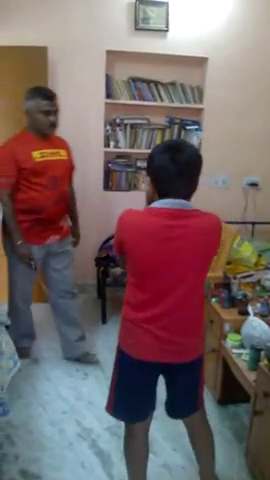

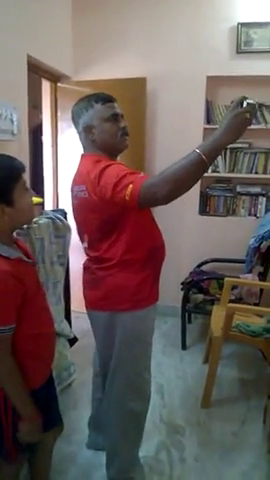

In [21]:
pre_data, post_data = ag[350]

pre_id = pre_data[0]
post_id = post_data[0]

print(pre_id)
print(post_id)

pre_image = pre_data[1]
post_image = post_data[1]

display(pre_image)
display(post_image)

[ 11.  60. 149. 115.]
[ 11.  60. 149. 115.]
[ 11.  60. 149. 115.]
[ 11.  60. 149. 115.]
[ 11.  60. 149. 115.]
[ 11.  60. 149. 115.]
[ 11.  60. 149. 115.]
[ 11.  60. 149. 115.]
[ 11.  60. 149. 115.]
[ 11.  60. 149.]
[ 11.  60. 149.]
[ 11.  60. 149.]
[ 11.  60. 149.]
[ 11.  60. 149.]
[ 11.  60. 149.]
[ 11.  60. 149.]
[ 11.  60. 149.]
[105.  11.  60. 149.]
[105.  11.  60. 149.]
[105.  11.  60. 149.]
[105.  11.  60.]
[105.  11.]
[105.  11.]
[105. 103.  11.]
[105. 103.  11. 106.]
[105. 103.  11. 106.]
[105. 103.  11. 106.]
[105. 103.  11. 106.]
[105. 103.  11. 106.]
[103.  11. 106.]
[103.  11. 106. 106.]
[103.  11. 106. 106.]
[103.  11. 106. 106.]
[103.  11. 106. 106.]
[103.  11. 106. 106.]
[103.  11. 106. 106.]
[103.  11. 106. 106.]
[103.  11. 106. 106.]
[103.  11. 106. 106.]
[103.  11. 106. 106.]
[103.  11. 106. 106.]
[ 11. 106. 106.]
[ 11. 106.]
[<PIL.Image.Image image mode=RGB size=480x270 at 0x7C1369FBF310>, <PIL.Image.Image image mode=RGB size=480x270 at 0x7C1369D6ADF0>, <PIL.Image.Im

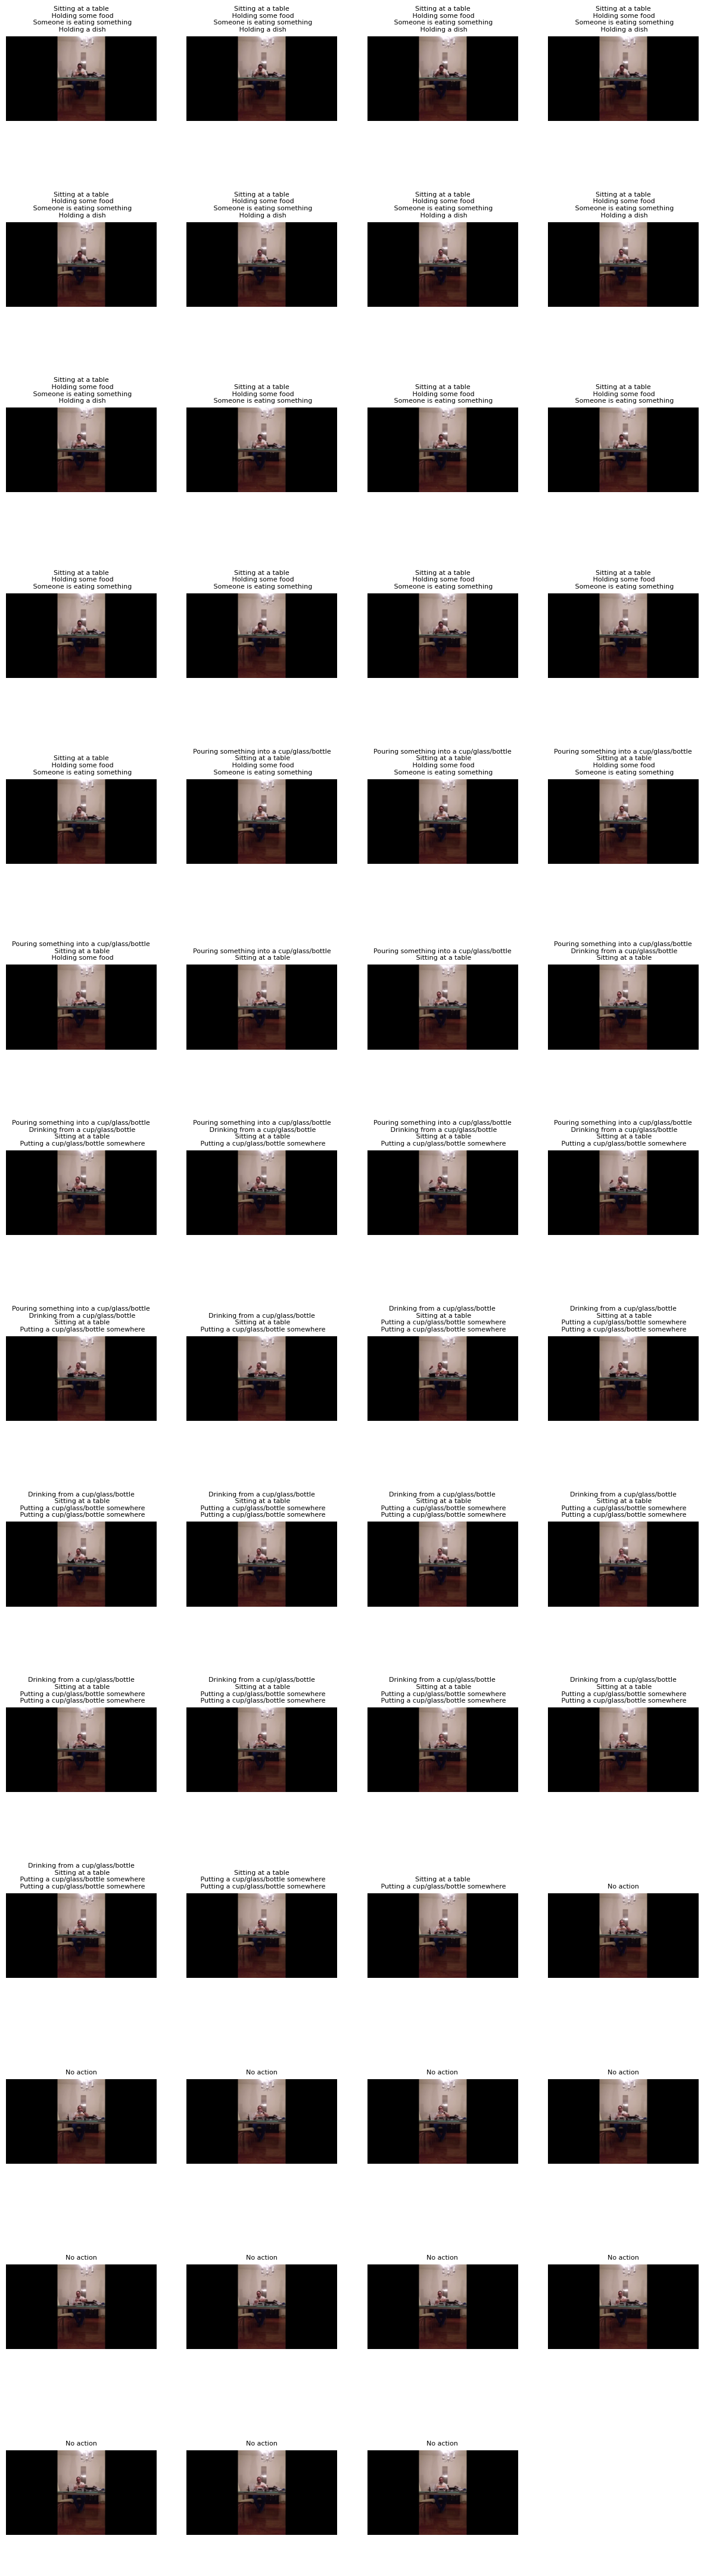

In [87]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def display_video_frames(video_id, root, action_df, limit=10, col=5, row_height=5, multi_label=False):
    images = []
    captions = []
    vid_dir = os.path.join(root, 'frames', f'{video_id}.mp4')
    frame_files = sorted(os.listdir(vid_dir))[:limit]  # Get all files up to the limit
    for frame_file in frame_files:
        image_path = os.path.join(vid_dir, frame_file)
        image = Image.open(image_path).convert('RGB')
        images.append(image)
        
        # Extract frame index from the file name
        frame_idx = int(os.path.splitext(frame_file)[0])
        
        # Check if there are actions associated with this frame
        action_rows = action_df[(action_df['vid'] == video_id) & 
                                ((action_df['pre_frame'] <= frame_idx) & (action_df['post_frame'] >= frame_idx))]
        if not action_rows.empty:
            print(action_rows['action'].values)
            if multi_label:
                actions = action_rows['action'].values
                action_names = [ag.action_classes[a] for a in actions]
                captions.append('\n'.join(action_names))
            else:
                action_names = [ag.action_classes[int(action)] for action in action_rows['action'].values]
                captions.append('\n '.join(action_names))
        else:
            captions.append('No action')
    print(images)
    
    rows = (len(images) + col - 1) // col  # Calculate the number of rows needed
    fig, axes = plt.subplots(rows, col, figsize=(15, row_height * rows))
    axes = axes.flatten()  # Flatten the axes array for easy iteration
    for ax, img, caption in zip(axes, images, captions):
        ax.imshow(img)
        ax.set_title(caption, fontsize=8)
        ax.axis('off')
    for ax in axes[len(images):]:  # Turn off any unused subplots
        ax.axis('off')
    plt.show()

# Example usage
#video_id = '00NN7'
#video_id = '001YG'
#video_id = 'WLOCV'
#video_id = '46GP8'
#video_id = 'N11GT'
#video_id = 'KRF68'
#video_id = 'MCQO5'
#video_id = 'JSUF4'
#video_id = '8WJIR'
#video_id = 'SX0HE'
#video_id = 'BDFDE'
#video_id = '3ZHEX'
video_id = 'OOWJ9'


display_video_frames(video_id, root, ag.df, limit=100, col=4, row_height=4, multi_label=False)

In [91]:
with open(os.path.join(root, 'annotations/Charades/Charades_v1_train.csv'), 'r') as f:
    raw_df = pd.read_csv(f)

# Split each row into one row per action, and split each action into its id, start and end time
def split_actions(row):
    if isinstance(row['actions'], str):
        actions = row['actions'].split(';')
    else:
        actions = []
    split_rows = []
    for action in actions:
        action_id, start_time, end_time = action.split()
        action_id = ag.action_mapper[int(action_id[1:])]
        if action_id is not None:
            action_name = ag.action_classes[action_id]
        else:
            action_name = 'unknown'
        split_rows.append({
            'id': row['id'],
            'action_id': action_id,
            'action_name': action_name,
            'start_time': float(start_time),
            'end_time': float(end_time),
            'frame_count': row['frame_count'],
            'length': row['length']
        })
    return split_rows

# Count the frames for each video and add this count as a new column to the df
def count_frames(video_id, root):
    vid_dir = os.path.join(root, 'frames', f'{video_id}.mp4')
    if os.path.exists(vid_dir):
        return len(os.listdir(vid_dir))
    else:
        return 0

pd.options.display.max_colwidth = 1000
raw_df['frame_count'] = raw_df['id'].apply(lambda x: count_frames(x, root))

# Apply the split_actions function to each row and create a new DataFrame
split_rows = []
for _, row in raw_df.iterrows():
    split_rows.extend(split_actions(row))

split_df = pd.DataFrame(split_rows)
#split_df[split_df['id'] == '001YG'].iloc[100:120]
split_df[split_df['action_id']==149][:50]
myaction_vid_ids = split_df[split_df['action_id']==149]['id'].unique()
print(myaction_vid_ids)


['S6MPZ' '72JYK' 'VHIG7' 'PSPMA' 'S673O' 'P68QV' '0VOQC' 'E6Q95' 'DWHPO'
 'H603E' 'PN4MI' 'IST7I' '57J92' 'R00LO' 'V3DJ5' 'XECIL' 'OOWJ9' 'UBVV7'
 'AX4EW' 'XCUOD' 'LWP5F' 'TU3IG' 'WFWTU' '3H0PT' 'R0207' 'FO2RD' '1X765'
 '94KP4' 'KW3BO' 'SXYLN' 'J39ZC' 'C5BMA' 'ZYVTC' 'PKEZI' 'MD6P2' '705RV'
 'AEZDA' 'WEYV3' 'BIK4X' 'A4SR3' 'CD11G' 'U6KQ7' 'T03KF' 'M1P59' 'X1RBM'
 'HKM3R' '1RB92' 'GT53K' 'NEM29' 'YUEB9' 'OA9W5' 'VSO80' 'HXCGX' 'X29NF'
 'HDX87' 'XUYCA' 'FBHBP' 'D2GQH' '5P0ON' 'V3RAX' 'MN1MC' 'WR2Q2' 'KJWAH'
 'Q4932' 'U2SJH' 'Z4P5B' 'Y2QUJ' 'FQNPB' 'DPCGS' '62VEF' 'P3EW1' 'MLBTH'
 '8X49S' 'D4XVH' 'AXJUB' 'SA9PB' '5CZRC' 'IS7PL' '04MTP' '9SZG2' 'SQBEE'
 '8Y7P5' '450TW' '0WU7S' 'D07V2' '4Y1AW' 'SUYMQ' '9OH7W' 'QO6RV' 'CBG3N'
 'JISS4' 'ZBDB5' '7JZTY' 'KRT78' 'OXUKR' 'UK8KW' 'JJKNY' 'H9F6S' 'NMTRI'
 'AXYF9' 'CEQM1' '406LH' 'LURLC' 'DCLLS' 'GVX7E' '432NL' 'LH6LE' '6E4L5'
 'PVC93' '0GR11' 'QJIAV' 'Z6ZYF' '9I42K' 'GK15U' 'B5X50' '0N8OZ' 'D6D85'
 'RS3SQ' 'RIUEI' 'JLX1D' 'OHLSE' 'VXRCZ' 'XXYWL' 'E

[15.]
[15.]
[15.]
[15.]
[15.]
[15.]
[15.]
[15.]
[15.]
[15.]
[ 15. 149.  60.]
[ 15. 149.  60.]
[ 15. 149.  60.]
[ 15. 149.  60.]
[ 15. 149.  60.]
[ 15. 149.  60.]
[ 15. 149.  60.]
[ 15. 149.]
[ 15. 149.]
[ 15.  23. 149.]
[ 20.  15.  23. 149.]
[ 20.  15.  23. 149.]
[ 20.  15.  23. 149.]
[ 20.  15.  23. 149.  94.]
[ 20.  15.  23. 149.  94.]
[ 20.  23. 149.  94.]
[ 23. 149.  94.]
[ 23. 149.  94.]
[ 23. 149.  94.]
[ 23. 149.  94.]
[ 23. 149.  94.]
[ 23. 149.  94.]
[<PIL.Image.Image image mode=RGB size=480x270 at 0x7C13699A3AF0>, <PIL.Image.Image image mode=RGB size=480x270 at 0x7C136A029640>, <PIL.Image.Image image mode=RGB size=480x270 at 0x7C1378AB14C0>, <PIL.Image.Image image mode=RGB size=480x270 at 0x7C1365ED5F70>, <PIL.Image.Image image mode=RGB size=480x270 at 0x7C13789D3160>, <PIL.Image.Image image mode=RGB size=480x270 at 0x7C1366CB2130>, <PIL.Image.Image image mode=RGB size=480x270 at 0x7C136A02F9A0>, <PIL.Image.Image image mode=RGB size=480x270 at 0x7C136C7FE310>, <PIL.Image.Imag

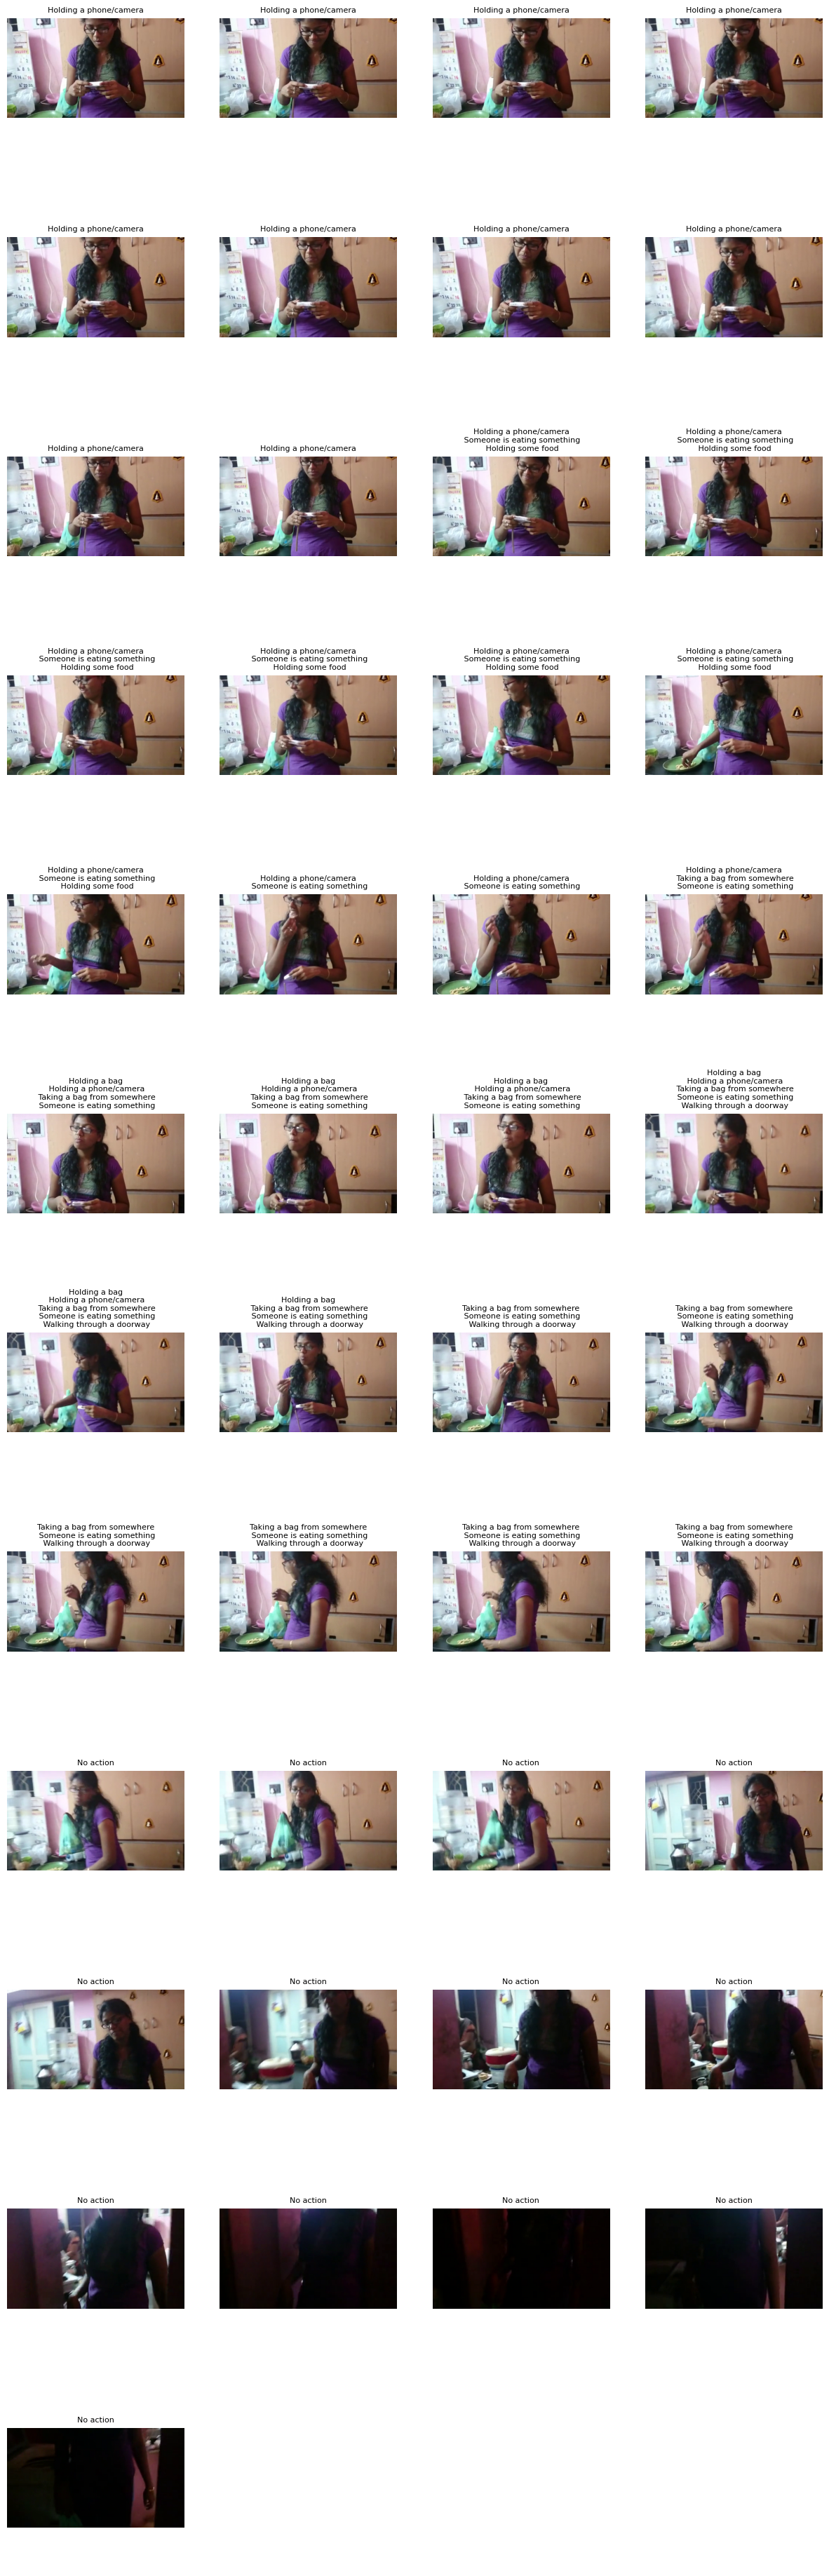

In [97]:
display_video_frames(myaction_vid_ids[5], root, ag.df, limit=100, col=4, row_height=4, multi_label=False)

In [ ]:
import subprocess

def get_framerate(video_id, root):
    vid_path = os.path.join(root, 'videos', f'{video_id}.mp4')
    if os.path.exists(vid_path):
        result = subprocess.run(
            ['ffprobe', '-v', '0', '-of', 'csv=p=0', '-select_streams', 'v:0', '-show_entries', 'stream=r_frame_rate', vid_path],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE
        )
        framerate = result.stdout.decode('utf-8').strip()
        print(vid_path, framerate)
        return framerate
    else:
        return '0/0'

raw_df['framerate'] = raw_df['id'].apply(lambda x: get_framerate(x, root))



                   Top 1 Acc  Top 5 Acc  Precision  Recall
Backbone only           21.4       49.6       15.0    23.2
Non-probabilistic       22.0       52.7       15.5    23.6
Rules only              22.2       78.5       19.9    27.4
Integrated              28.5       77.7       22.9    31.0


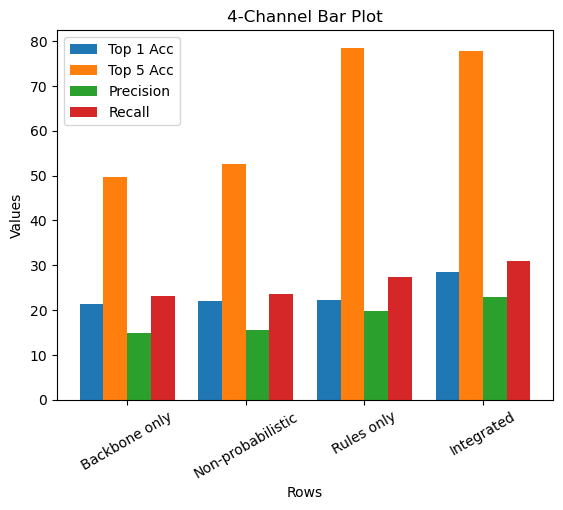

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 4x4 table with placeholder data
data = {
    'Top 1 Acc': [21.4, 22.0, 22.2, 28.5],
    'Top 5 Acc': [49.6, 52.7, 78.5, 77.7],
    'Precision': [15.0, 15.5, 19.9, 22.9],
    'Recall': [23.2, 23.6, 27.4, 31.0]
}

# Convert the data into a DataFrame
df = pd.DataFrame(data, index=['Backbone only', 'Non-probabilistic', 'Rules only', 'Integrated'])
print(df)

# Create a 4-channel bar plot using the data
fig, ax = plt.subplots()

bar_width = 0.2
index = np.arange(len(df))

bar1 = ax.bar(index, df['Top 1 Acc'], bar_width, label='Top 1 Acc')
bar2 = ax.bar(index + bar_width, df['Top 5 Acc'], bar_width, label='Top 5 Acc')
bar3 = ax.bar(index + 2 * bar_width, df['Precision'], bar_width, label='Precision')
bar4 = ax.bar(index + 3 * bar_width, df['Recall'], bar_width, label='Recall')

ax.set_xlabel('Rows')
ax.set_ylabel('Values')
ax.set_title('4-Channel Bar Plot')
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels(df.index, rotation=30)  # Tilt labels at a 30 degree angle
ax.legend()

plt.show()


Original Data:
                   Top 1 Acc  Top 5 Acc  Precision  Recall
Backbone only           21.4       49.6       15.0    23.2
Non-probabilistic       22.0       52.7       15.5    23.6
Rules only              22.2       78.5       19.9    27.4
Integrated              28.5       77.7       22.9    31.0

Normalized Data:
                   Top 1 Acc  Top 5 Acc  Precision    Recall
Backbone only       1.000000   1.000000   1.000000  1.000000
Non-probabilistic   1.028037   1.062500   1.033333  1.017241
Rules only          1.037383   1.582661   1.326667  1.181034
Integrated          1.331776   1.566532   1.526667  1.336207


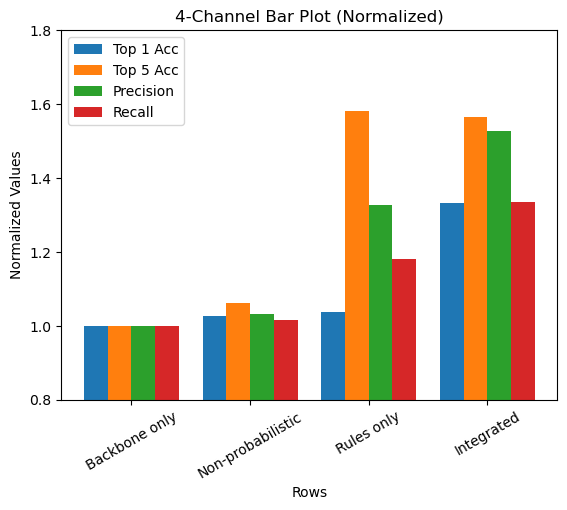

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 4x4 table with placeholder data
data = {
    'Top 1 Acc': [21.4, 22.0, 22.2, 28.5],
    'Top 5 Acc': [49.6, 52.7, 78.5, 77.7],
    'Precision': [15.0, 15.5, 19.9, 22.9],
    'Recall': [23.2, 23.6, 27.4, 31.0]
}

# Convert the data into a DataFrame
df = pd.DataFrame(data, index=['Backbone only', 'Non-probabilistic', 'Rules only', 'Integrated'])
print("Original Data:")
print(df)

# Normalize the values relative to 'Backbone only'
df_normalized = df.div(df.loc['Backbone only'])
print("\nNormalized Data:")
print(df_normalized)

# Create a 4-channel bar plot using the normalized data
fig, ax = plt.subplots()

bar_width = 0.2
index = np.arange(len(df_normalized))

bar1 = ax.bar(index, df_normalized['Top 1 Acc'], bar_width, label='Top 1 Acc')
bar2 = ax.bar(index + bar_width, df_normalized['Top 5 Acc'], bar_width, label='Top 5 Acc')
bar3 = ax.bar(index + 2 * bar_width, df_normalized['Precision'], bar_width, label='Precision')
bar4 = ax.bar(index + 3 * bar_width, df_normalized['Recall'], bar_width, label='Recall')

ax.set_xlabel('Rows')
ax.set_ylabel('Normalized Values')
ax.set_title('4-Channel Bar Plot (Normalized)')
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels(df.index, rotation=30)  # Tilt labels at a 30 degree angle
ax.legend()

ax.set_ylim(0.8, 1.8)

plt.show()


          Method  Top 1 Acc  Top 5 Acc  Precision  Recall
0  Backbone only       21.4       49.6       15.0    23.2
1     Rules only       22.2       78.5       19.9    27.4
2     Integrated       28.5       77.7       22.9    31.0
Method     Backbone only  Rules only  Integrated
Top 1 Acc           21.4        22.2        28.5
Top 5 Acc           49.6        78.5        77.7
Precision           15.0        19.9        22.9
Recall              23.2        27.4        31.0


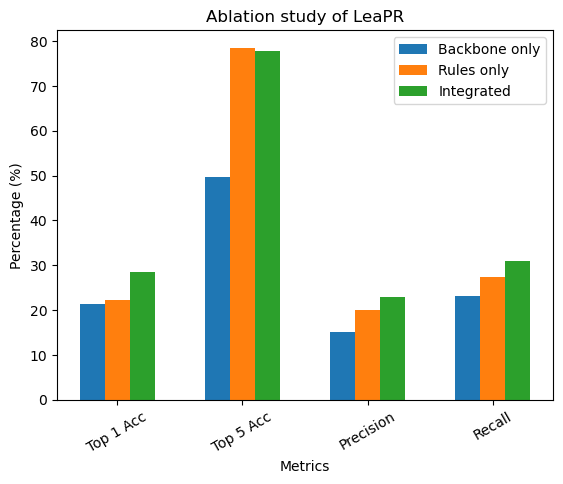

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 3x4 table with placeholder data
data = {
    'Method': ['Backbone only', 'Rules only', 'Integrated'],
    'Top 1 Acc': [21.4, 22.2, 28.5],
    'Top 5 Acc': [49.6, 78.5, 77.7],
    'Precision': [15.0, 19.9, 22.9],
    'Recall': [23.2, 27.4, 31.0]
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
print(df)

# Transpose the DataFrame to group by metric
df_transposed = df.set_index('Method').T
print(df_transposed)

# Create a 3-channel bar plot using the transposed data
fig, ax = plt.subplots()

bar_width = 0.2
index = np.arange(len(df_transposed))

bar1 = ax.bar(index, df_transposed['Backbone only'], bar_width, label='Backbone only')
bar2 = ax.bar(index + bar_width, df_transposed['Rules only'], bar_width, label='Rules only')
bar3 = ax.bar(index + 2 * bar_width, df_transposed['Integrated'], bar_width, label='Integrated')

ax.set_xlabel('Metrics')
ax.set_ylabel('Percentage (%)')
ax.set_title('Ablation study of LeaPR')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(df_transposed.index, rotation=30)  # Tilt labels at a 30 degree angle
ax.legend()

plt.show()


              Method  Top 1 Acc  Top 5 Acc  Precision  Recall
0      Backbone only       21.4       49.6       15.0    23.2
1  Non-probabilistic       22.0       52.7       15.5    23.6
2         Rules only       22.2       78.5       19.9    27.4
3         Integrated       28.5       77.7       22.9    31.0
                   Top 1 Acc  Top 5 Acc  Precision    Recall
Method                                                      
Backbone only       1.000000   1.000000   1.000000  1.000000
Non-probabilistic   1.028037   1.062500   1.033333  1.017241
Rules only          1.037383   1.582661   1.326667  1.181034
Integrated          1.331776   1.566532   1.526667  1.336207
Method     Backbone only  Non-probabilistic  Rules only  Integrated
Top 1 Acc            1.0           1.028037    1.037383    1.331776
Top 5 Acc            1.0           1.062500    1.582661    1.566532
Precision            1.0           1.033333    1.326667    1.526667
Recall               1.0           1.017241    1.181

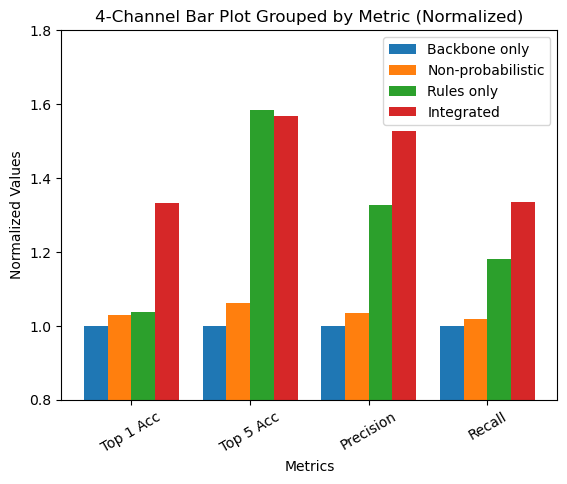

In [29]:

import matplotlib.pyplot as plt
import numpy as np

# Create a 4x4 table with placeholder data
data = {
    'Method': ['Backbone only', 'Non-probabilistic', 'Rules only', 'Integrated'],
    'Top 1 Acc': [21.4, 22.0, 22.2, 28.5],
    'Top 5 Acc': [49.6, 52.7, 78.5, 77.7],
    'Precision': [15.0, 15.5, 19.9, 22.9],
    'Recall': [23.2, 23.6, 27.4, 31.0]
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
print(df)

# Normalize the data relative to the 'Backbone only' method
df_normalized = df.set_index('Method').div(df.set_index('Method').loc['Backbone only'])
print(df_normalized)

# Transpose the normalized DataFrame to group by metric
df_transposed = df_normalized.T
print(df_transposed)

# Create a 4-channel bar plot using the transposed normalized data
fig, ax = plt.subplots()

bar_width = 0.2
index = np.arange(len(df_transposed.columns))

bar1 = ax.bar(index, df_transposed['Backbone only'], bar_width, label='Backbone only')
bar2 = ax.bar(index + bar_width, df_transposed['Non-probabilistic'], bar_width, label='Non-probabilistic')
bar3 = ax.bar(index + 2 * bar_width, df_transposed['Rules only'], bar_width, label='Rules only')
bar4 = ax.bar(index + 3 * bar_width, df_transposed['Integrated'], bar_width, label='Integrated')

ax.set_xlabel('Metrics')
ax.set_ylabel('Normalized Values')
ax.set_title('4-Channel Bar Plot Grouped by Metric (Normalized)')
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels(df_transposed.index, rotation=30)  # Tilt labels at a 30 degree angle
ax.legend()

# Adjust the y-axis range to make differences more pronounced
ax.set_ylim(0.8, 1.8)

plt.show()
